In [42]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split

In [43]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

x_train_cnn = x_train.reshape(-1, 28, 28, 1)
x_test_cnn = x_test.reshape(-1, 28, 28, 1)

x_train_fnn = x_train.reshape(-1, 784)
x_test_fnn = x_test.reshape(-1, 784)

In [44]:
cnn = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

cnn.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [45]:
fnn = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

fnn.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [46]:
history_cnn = cnn.fit(x_train_cnn, y_train,
                       validation_split=0.2,
                       epochs=5,
                       verbose=1)

history_fnn = fnn.fit(x_train_fnn, y_train,
                      validation_split=0.2,
                      epochs=5,
                      verbose=1)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 50s 32ms/step - accuracy: 0.9556 - loss: 0.1423 - val_accuracy: 0.9783 - val_loss: 0.0671
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 53s 36ms/step - accuracy: 0.9849 - loss: 0.0491 - val_accuracy: 0.9862 - val_loss: 0.0475
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 46s 31ms/step - accuracy: 0.9895 - loss: 0.0328 - val_accuracy: 0.9898 - val_loss: 0.0388
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 84s 33ms/step - accuracy: 0.9922 - loss: 0.0235 - val_accuracy: 0.9877 - val_loss: 0.0408
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 46s 31ms/step - accuracy: 0.9944 - loss: 0.0173 - val_accuracy: 0.9894 - val_loss: 0.0436
Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9315 - loss: 0.2305 - val_accuracy: 0.9633 - val_loss: 0.1225
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9712 - loss: 0.0928 - val_accuracy: 0.9702 - val_loss: 0.1006
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9802 - loss: 0.06

In [47]:
cnn_acc = cnn.evaluate(x_test_cnn, y_test, verbose=0)[1]
fnn_acc = fnn.evaluate(x_test_fnn, y_test, verbose=0)[1]

print("CNN Accuracy:", cnn_acc)
print("FNN Accuracy:", fnn_acc)

CNN Accuracy: 0.9889000058174133
FNN Accuracy: 0.9794999957084656


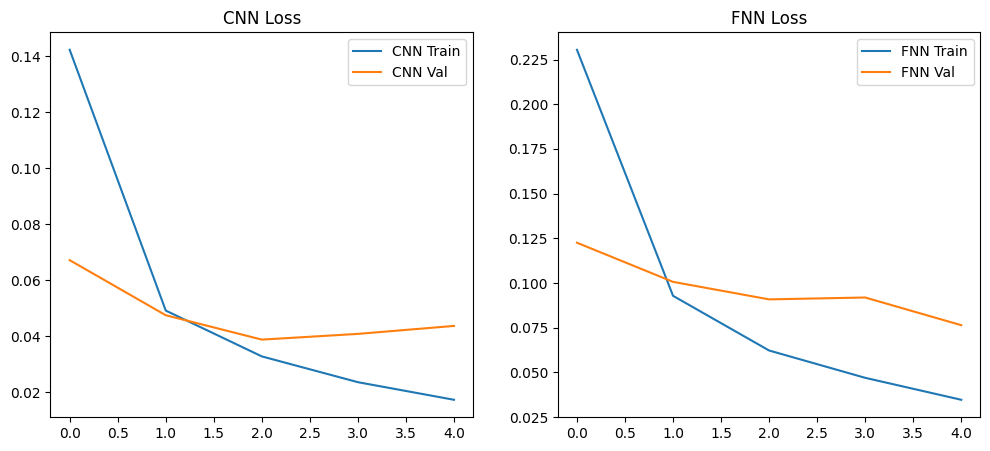

In [48]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_cnn.history['loss'], label='CNN Train')
plt.plot(history_cnn.history['val_loss'], label='CNN Val')
plt.title("CNN Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_fnn.history['loss'], label='FNN Train')
plt.plot(history_fnn.history['val_loss'], label='FNN Val')
plt.title("FNN Loss")
plt.legend()

plt.show()

In [49]:
cnn_params = cnn.count_params()
fnn_params = fnn.count_params()

print("CNN Parameters:", cnn_params)
print("FNN Parameters:", fnn_params)

CNN Parameters: 225034
FNN Parameters: 235146


In [50]:
cnn.save("cnn_mnist.keras")
fnn.save("fnn_mnist.keras")

In [51]:
from google.colab import files

files.download("cnn_mnist.keras")
files.download("fnn_mnist.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

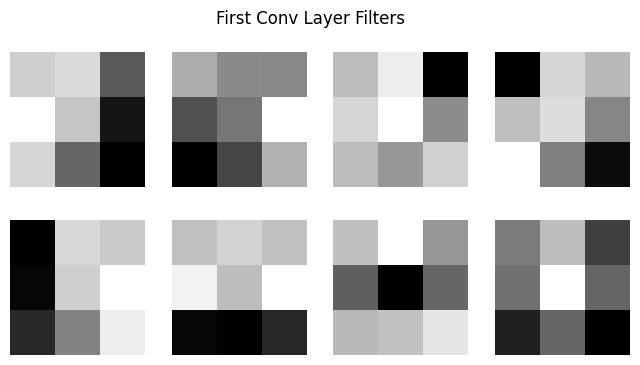

In [52]:
filters, biases = cnn.layers[0].get_weights()

fig, axes = plt.subplots(2, 4, figsize=(8,4))

for i in range(8):
    f = filters[:, :, 0, i]
    axes[i//4, i%4].imshow(f, cmap='gray')
    axes[i//4, i%4].axis('off')

plt.suptitle("First Conv Layer Filters")
plt.show()

In [55]:
inputs = keras.Input(shape=(28,28,1))

x = layers.Conv2D(32, (3,3), activation='relu')(inputs)
x = layers.MaxPooling2D((2,2))(x)

x = layers.Conv2D(64, (3,3), activation='relu')(x)
x = layers.MaxPooling2D((2,2))(x)

x = layers.Flatten()(x)
x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(10, activation='softmax')(x)

cnn = keras.Model(inputs, outputs)

In [56]:
print("""
CONCLUSION:

1. CNN achieved higher accuracy than FNN because:
   It learns spatial features using filters
   Pooling reduces dimensional complexity

2. FNN uses many parameters because:
   Every pixel is fully connected to every neuron

3. CNN uses fewer parameters because:
   Shared weights (filters)
   Local connectivity (not fully connected layers)

FINAL RESULT:
CNN is more efficient and performs better on image data than FNN.
""")


CONCLUSION:

1. CNN achieved higher accuracy than FNN because:
   It learns spatial features using filters
   Pooling reduces dimensional complexity

2. FNN uses many parameters because:
   Every pixel is fully connected to every neuron

3. CNN uses fewer parameters because:
   Shared weights (filters)
   Local connectivity (not fully connected layers)

FINAL RESULT:
CNN is more efficient and performs better on image data than FNN.

